In [1]:
# Install Kaggle
!pip install kaggle

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Upload your kaggle.json file (you'll need to upload it manually from your local machine)
from google.colab import files
files.upload()  # Upload your kaggle.json file here

# Move and set permissions
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Verify installation
!kaggle --version

Saving kaggle.json to kaggle.json
Kaggle API 1.7.4.5


In [2]:
# Download the dataset
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

# Unzip it
!unzip lgg-mri-segmentation.zip -d lgg-mri-segmentation

# Check contents
!ls -R lgg-mri-segmentation | head -n 30

Streaming output truncated to the last 5000 lines.
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_23.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_23_mask.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_24.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_24_mask.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_25.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_25_mask.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_26.tif  
  inflating: lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324

In [3]:
import os
import glob

# Define the base directory
base_dir = 'lgg-mri-segmentation'

# Check if the directory exists
if not os.path.exists(base_dir):
    print(f"Directory {base_dir} does not exist. Please check your download.")
else:
    # Get all patient folders
    patient_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
    print(f"Found {len(patient_folders)} patient folders.")

    # Check first few folders to verify structure
    for i, folder in enumerate(patient_folders[:3]):
        folder_path = os.path.join(base_dir, folder)
        files = os.listdir(folder_path)
        print(f"\nFolder {folder}:")
        for file in files[:5]:  # Show first 5 files
            print(f"  - {file}")

Found 2 patient folders.

Folder lgg-mri-segmentation:
  - kaggle_3m

Folder kaggle_3m:
  - TCGA_FG_6690_20020226
  - TCGA_DU_5874_19950510
  - TCGA_HT_7855_19951020
  - TCGA_HT_7690_19960312
  - TCGA_CS_5395_19981004


Getting file paths...
Found 110 patient folders
Found 3929 image-mask pairs
Training set: 2750 samples
Validation set: 589 samples
Test set: 590 samples

Loading a small batch to verify...
Sample batch shape: (10, 224, 224, 3)
Sample masks shape: (10, 224, 224)

Mask statistics:
Mask 0: unique values = [0.], shape = (224, 224)
  White pixels (tumor): 0
  Black pixels (background): 50176
Mask 1: unique values = [0. 1.], shape = (224, 224)
  White pixels (tumor): 998
  Black pixels (background): 49178
Mask 2: unique values = [0.], shape = (224, 224)
  White pixels (tumor): 0
  Black pixels (background): 50176
Mask 3: unique values = [0.], shape = (224, 224)
  White pixels (tumor): 0
  Black pixels (background): 50176
Mask 4: unique values = [0. 1.], shape = (224, 224)
  White pixels (tumor): 1178
  Black pixels (background): 48998


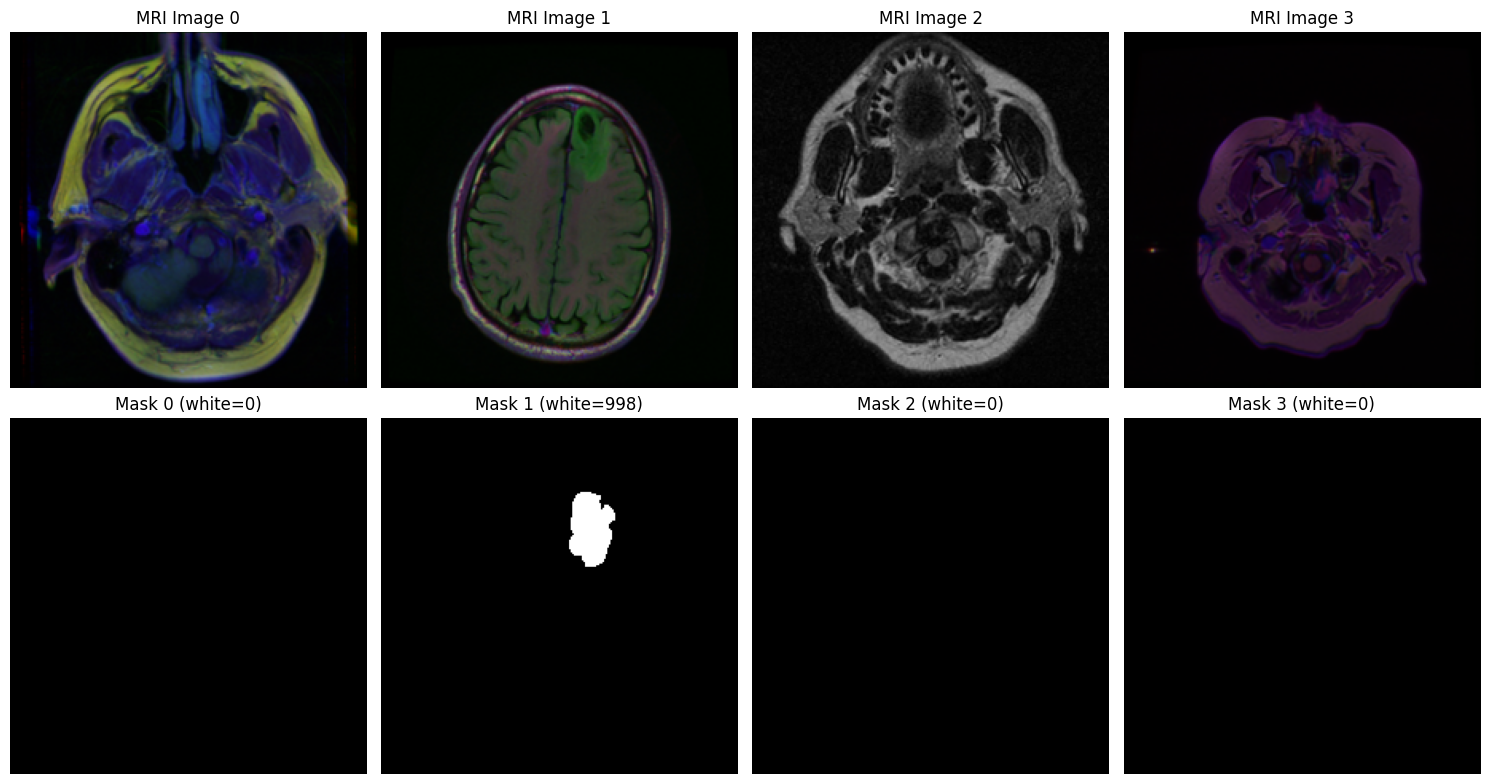


Displaying image with mask overlay...


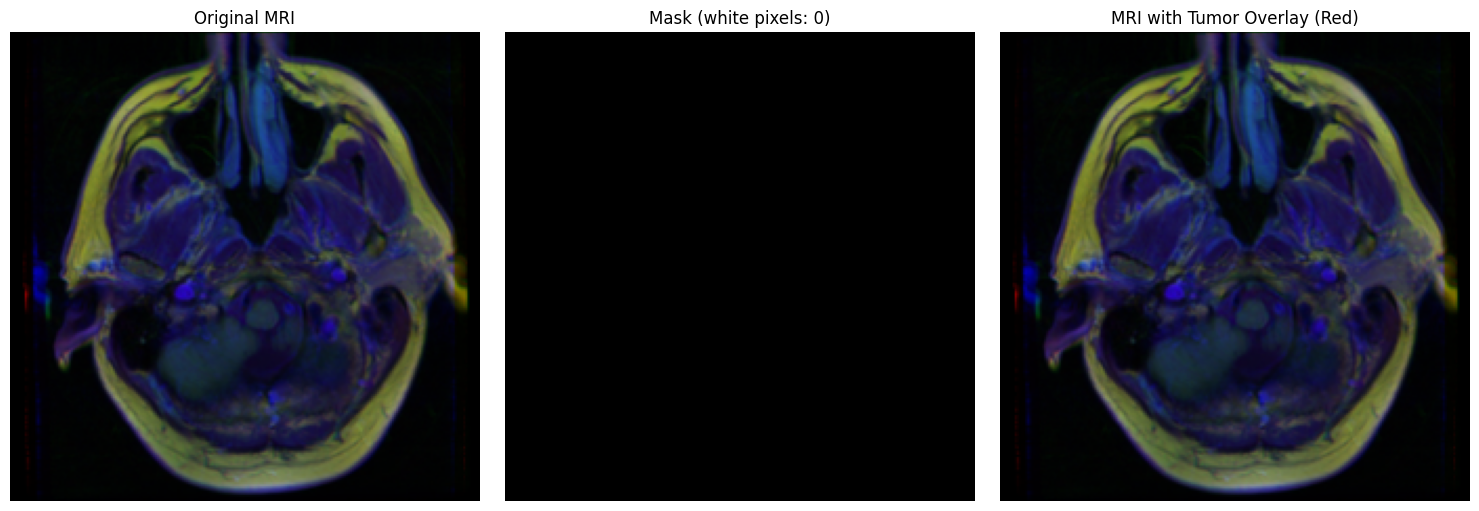


Checking for empty masks in entire dataset (first 100 samples)...
Empty masks (no tumor): 79/100 = 79.00%


In [2]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import gc

def get_file_paths(base_dir):
    """
    Get all image and mask file paths without loading them
    """
    data_dir = os.path.join(base_dir, 'kaggle_3m')
    image_paths = []
    mask_paths = []

    if not os.path.exists(data_dir):
        raise ValueError(f"Data directory {data_dir} does not exist!")

    patient_folders = [f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))
                      and not f.startswith('.')]

    print(f"Found {len(patient_folders)} patient folders")

    for folder in patient_folders:
        folder_path = os.path.join(data_dir, folder)
        files = os.listdir(folder_path)

        mask_files = [f for f in files if f.endswith('_mask.tif')]

        for mask_file in mask_files:
            mask_path = os.path.join(folder_path, mask_file)
            image_file = mask_file.replace('_mask.tif', '.tif')
            image_path = os.path.join(folder_path, image_file)

            if os.path.exists(image_path) and os.path.exists(mask_path):
                image_paths.append(image_path)
                mask_paths.append(mask_path)

    return image_paths, mask_paths

def load_batch(image_paths, mask_paths, batch_indices, img_size=(224, 224), normalize=True):
    """
    Load a batch of images and masks
    """
    batch_images = []
    batch_masks = []

    for idx in batch_indices:
        # Load image
        image = cv2.imread(image_paths[idx])
        if image is not None:
            image = cv2.resize(image, img_size)
            if normalize:
                image = image / 255.0
            batch_images.append(image)

        # Load mask
        mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            mask = cv2.resize(mask, img_size)
            # IMPORTANT: Masks ko binary bana do (0 ya 1)
            mask = (mask > 0).astype(np.float32)
            if normalize:
                mask = mask.astype(np.float32)  # Already 0 or 1
            batch_masks.append(mask)

    return np.array(batch_images), np.array(batch_masks)

# Main script
print("Getting file paths...")
base_dir = 'lgg-mri-segmentation'

try:
    image_paths, mask_paths = get_file_paths(base_dir)
    print(f"Found {len(image_paths)} image-mask pairs")

    if len(image_paths) == 0:
        raise ValueError("No images found!")

    # Split indices instead of data
    indices = np.arange(len(image_paths))
    train_indices, temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42)

    print(f"Training set: {len(train_indices)} samples")
    print(f"Validation set: {len(val_indices)} samples")
    print(f"Test set: {len(test_indices)} samples")

    # Load a small batch to verify - NORMALIZE NAHI KARENGE DISPLAY KE LIYE
    print("\nLoading a small batch to verify...")
    sample_batch, sample_masks = load_batch(image_paths, mask_paths, train_indices[:10], normalize=False)
    print(f"Sample batch shape: {sample_batch.shape}")
    print(f"Sample masks shape: {sample_masks.shape}")

    # Masks ki information check karein
    print("\nMask statistics:")
    for i in range(min(5, len(sample_masks))):
        unique_vals = np.unique(sample_masks[i])
        print(f"Mask {i}: unique values = {unique_vals}, shape = {sample_masks[i].shape}")
        print(f"  White pixels (tumor): {np.sum(sample_masks[i] > 0)}")
        print(f"  Black pixels (background): {np.sum(sample_masks[i] == 0)}")

    # Display multiple samples to check
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))

    for i in range(4):
        # MRI Image display (BGR to RGB for proper colors)
        img_display = cv2.cvtColor(sample_batch[i], cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img_display)
        axes[0, i].set_title(f'MRI Image {i}')
        axes[0, i].axis('off')

        # Mask display - binary colormap use karein
        mask_display = sample_masks[i]
        # Check if mask has any white pixels
        if np.max(mask_display) > 0:
            axes[1, i].imshow(mask_display, cmap='gray', vmin=0, vmax=1)
        else:
            axes[1, i].imshow(mask_display, cmap='gray')
        axes[1, i].set_title(f'Mask {i} (white={np.sum(mask_display>0)})')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Ek aur display with overlay
    print("\nDisplaying image with mask overlay...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    img_idx = 0
    img_rgb = cv2.cvtColor(sample_batch[img_idx], cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original MRI')
    axes[0].axis('off')

    # Mask only
    mask = sample_masks[img_idx]
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Mask (white pixels: {np.sum(mask>0)})')
    axes[1].axis('off')

    # Overlay
    overlay = img_rgb.copy()
    # Red overlay where mask is white
    overlay[mask > 0] = [255, 0, 0]  # Red color
    axes[2].imshow(overlay)
    axes[2].set_title('MRI with Tumor Overlay (Red)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Check for masks with no tumor (all black)
    print("\nChecking for empty masks in entire dataset (first 100 samples)...")
    empty_masks_count = 0
    total_checked = 100

    for i in range(min(total_checked, len(image_paths))):
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            mask_resized = cv2.resize(mask, (224, 224))
            mask_binary = (mask_resized > 0).astype(np.float32)
            if np.max(mask_binary) == 0:
                empty_masks_count += 1

    print(f"Empty masks (no tumor): {empty_masks_count}/{total_checked} = {empty_masks_count/total_checked*100:.2f}%")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()
    print("\nTroubleshooting steps:")
    print("1. Check if the dataset is downloaded correctly")
    print("2. Check the directory structure")
    print("3. Check available memory")

In [4]:
# First install tensorflow-addons
!pip install tensorflow-addons -q

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import gc

print("TensorFlow version:", tf.__version__)

# ============================================================================
# DATA LOADING (From previous steps)
# ============================================================================

def get_file_paths(base_dir):
    """
    Get all image and mask file paths without loading them
    """
    data_dir = os.path.join(base_dir, 'kaggle_3m')
    image_paths = []
    mask_paths = []

    if not os.path.exists(data_dir):
        raise ValueError(f"Data directory {data_dir} does not exist!")

    patient_folders = [f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))
                      and not f.startswith('.')]

    print(f"Found {len(patient_folders)} patient folders")

    for folder in patient_folders:
        folder_path = os.path.join(data_dir, folder)
        files = os.listdir(folder_path)

        mask_files = [f for f in files if f.endswith('_mask.tif')]

        for mask_file in mask_files:
            mask_path = os.path.join(folder_path, mask_file)
            image_file = mask_file.replace('_mask.tif', '.tif')
            image_path = os.path.join(folder_path, image_file)

            if os.path.exists(image_path) and os.path.exists(mask_path):
                image_paths.append(image_path)
                mask_paths.append(mask_path)

    return image_paths, mask_paths

print("Getting file paths...")
base_dir = 'lgg-mri-segmentation'
image_paths, mask_paths = get_file_paths(base_dir)
print(f"Found {len(image_paths)} image-mask pairs")

# Split indices
indices = np.arange(len(image_paths))
train_indices, temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42)

print(f"Training set: {len(train_indices)} samples")
print(f"Validation set: {len(val_indices)} samples")
print(f"Test set: {len(test_indices)} samples")

TensorFlow version: 2.19.0
Getting file paths...
Found 110 patient folders
Found 3929 image-mask pairs
Training set: 2750 samples
Validation set: 589 samples
Test set: 590 samples


In [6]:
# ============================================================================
# CUSTOM METRICS AND LOSS FUNCTIONS (Without tensorflow_addons)
# ============================================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient for segmentation evaluation
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Dice loss
    """
    return 1 - dice_coefficient(y_true, y_pred)

def tversky_index(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    """
    Tversky index for imbalanced data
    alpha: weight for false positives
    beta: weight for false negatives
    """
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    true_pos = K.sum(y_true * y_pred)
    false_neg = K.sum(y_true * (1 - y_pred))
    false_pos = K.sum((1 - y_true) * y_pred)

    return (true_pos + smooth) / (true_pos + alpha * false_pos + beta * false_neg + smooth)

def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7):
    """
    Tversky loss
    """
    return 1 - tversky_index(y_true, y_pred, alpha, beta)

def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=0.75):
    """
    Focal Tversky loss
    """
    tversky = tversky_index(y_true, y_pred, alpha, beta)
    return K.pow((1 - tversky), gamma)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """
    Intersection over Union metric
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """
    Focal loss for handling class imbalance
    """
    y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
    cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
    weight = alpha * y_true * K.pow(1 - y_pred, gamma) + (1 - alpha) * (1 - y_true) * K.pow(y_pred, gamma)
    loss = weight * cross_entropy
    return K.mean(loss)

def combined_loss(y_true, y_pred, alpha=0.5, beta=0.5):
    """
    Combined Dice + Focal loss
    """
    dice = dice_loss(y_true, y_pred)
    focal = focal_loss(y_true, y_pred)
    return alpha * dice + beta * focal

**Final Code**

TensorFlow version: 2.19.0
Mixed precision disabled - using float32
Getting file paths...
Found 110 patient folders
Found 3929 image-mask pairs
Training set: 2750 samples
Validation set: 589 samples
Test set: 590 samples
🧠 BRAIN TUMOR SEGMENTATION (FIXED DTYPE VERSION)

Attempting ResNet50 UNet training...

TRAINING RESNET50-UNET

Feature map shapes:
skip1: (None, 112, 112, 64)
skip2: (None, 56, 56, 256)
skip3: (None, 28, 28, 512)
skip4: (None, 14, 14, 1024)
bridge: (None, 7, 7, 2048)


Model: "ResNet50_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 59,857,537 (228.34 MB)

 Trainable params: 55,714,689 (212.53 MB)

...

344/344 ━━━━━━━━━━━━━━━━━━━━ 108s 314ms/step - binary_accuracy: 0.9907 - dice_coefficient: 0.5354 - iou_metric: 0.4001 - loss: 0.4568 - precision: 0.5943 - recall: 0.6130 - val_binary_accuracy: 0.9923 - val_dice_coefficient: 0.5323 - val_iou_metric: 0.4029 - val_loss: 0.5011 - val_precision: 0.8173 - val_recall: 0.4860 - learning_rate: 5.0000e-05
Epoch 12/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - binary_accuracy: 0.9907 - dice_coefficient: 0.5470 - iou_metric: 0.4134 - loss: 0.4350 - precision: 0.5642 - recall: 0.6661
Epoch 12: val_dice_coefficient did not improve from 0.53231
344/344 ━━━━━━━━━━━━━━━━━━━━ 92s 268ms/step - binary_accuracy: 0.9907 - dice_coefficient: 0.5470 - iou_metric: 0.4133 - loss: 0.4350 - precision: 0.5642 - recall: 0.6660 - val_binary_accuracy: 0.6625 - val_dice_coefficient: 0.0640 - val_iou_metric: 0.0336 - val_loss: 0.8989 - val_precision: 0.0346 - val_recall: 0.9806 - learning_rate: 5.0000e-05
Epoch 13/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - binar

344/344 ━━━━━━━━━━━━━━━━━━━━ 106s 309ms/step - binary_accuracy: 0.9929 - dice_coefficient: 0.6087 - iou_metric: 0.4726 - loss: 0.3749 - precision: 0.6703 - recall: 0.7015 - val_binary_accuracy: 0.9933 - val_dice_coefficient: 0.5894 - val_iou_metric: 0.4531 - val_loss: 0.4477 - val_precision: 0.8708 - val_recall: 0.5342 - learning_rate: 1.2500e-05
Epoch 24/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - binary_accuracy: 0.9928 - dice_coefficient: 0.6201 - iou_metric: 0.4797 - loss: 0.3691 - precision: 0.6732 - recall: 0.6764
Epoch 24: val_dice_coefficient improved from 0.58943 to 0.61454, saving model to best_resnet50_unet.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 114s 331ms/step - binary_accuracy: 0.9928 - dice_coefficient: 0.6201 - iou_metric: 0.4797 - loss: 0.3691 - precision: 0.6732 - recall: 0.6765 - val_binary_accuracy: 0.9937 - val_dice_coefficient: 0.6145 - val_iou_metric: 0.4794 - val_loss: 0.4195 - val_precision: 0.8733 - val_recall: 0.5690 - learning_rate: 1.2500e-05
Epoch 25/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - binary_accuracy: 0.9926 - dice_coefficient: 0.6190 - iou_metric: 0.4817 - loss: 0.3660 - precision: 0.6710 - recall: 0.7105
Epoch 25: val_dice_coefficient did not improve from 0.61454
344/344 ━━━━━━━━━━━━━━━━━━━━ 93s 269ms/step - binary_accuracy: 0.9926 - dice_coefficient: 0.6190 - iou_metric: 0.4817 - loss: 0.3660 - precision: 0.6709 - recall: 0.7105 - val_binary_accuracy: 0.6902 - val_dice_coefficient: 0.0681 - val_iou_metric: 0.0358 - val_loss: 0.8930 - val_precision: 0.0370 - val_recall: 0.9640 - learning_rate: 1.2500e-05
Epoch 26/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - binar

344/344 ━━━━━━━━━━━━━━━━━━━━ 120s 349ms/step - binary_accuracy: 0.9933 - dice_coefficient: 0.6278 - iou_metric: 0.4879 - loss: 0.3562 - precision: 0.6808 - recall: 0.6975 - val_binary_accuracy: 0.9941 - val_dice_coefficient: 0.6483 - val_iou_metric: 0.5143 - val_loss: 0.3752 - val_precision: 0.8517 - val_recall: 0.6304 - learning_rate: 1.2500e-05
Epoch 29/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - binary_accuracy: 0.9928 - dice_coefficient: 0.6038 - iou_metric: 0.4698 - loss: 0.3822 - precision: 0.6559 - recall: 0.7059
Epoch 29: val_dice_coefficient improved from 0.64833 to 0.65820, saving model to best_resnet50_unet.h5


344/344 ━━━━━━━━━━━━━━━━━━━━ 104s 302ms/step - binary_accuracy: 0.9928 - dice_coefficient: 0.6038 - iou_metric: 0.4698 - loss: 0.3821 - precision: 0.6560 - recall: 0.7059 - val_binary_accuracy: 0.9933 - val_dice_coefficient: 0.6582 - val_iou_metric: 0.5217 - val_loss: 0.3258 - val_precision: 0.7159 - val_recall: 0.7502 - learning_rate: 1.2500e-05
Epoch 30/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - binary_accuracy: 0.9930 - dice_coefficient: 0.6179 - iou_metric: 0.4825 - loss: 0.3617 - precision: 0.6510 - recall: 0.7236
Epoch 30: val_dice_coefficient did not improve from 0.65820
344/344 ━━━━━━━━━━━━━━━━━━━━ 92s 268ms/step - binary_accuracy: 0.9930 - dice_coefficient: 0.6178 - iou_metric: 0.4825 - loss: 0.3618 - precision: 0.6510 - recall: 0.7236 - val_binary_accuracy: 0.9919 - val_dice_coefficient: 0.6203 - val_iou_metric: 0.4781 - val_loss: 0.3509 - val_precision: 0.6482 - val_recall: 0.7579 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 29.

E

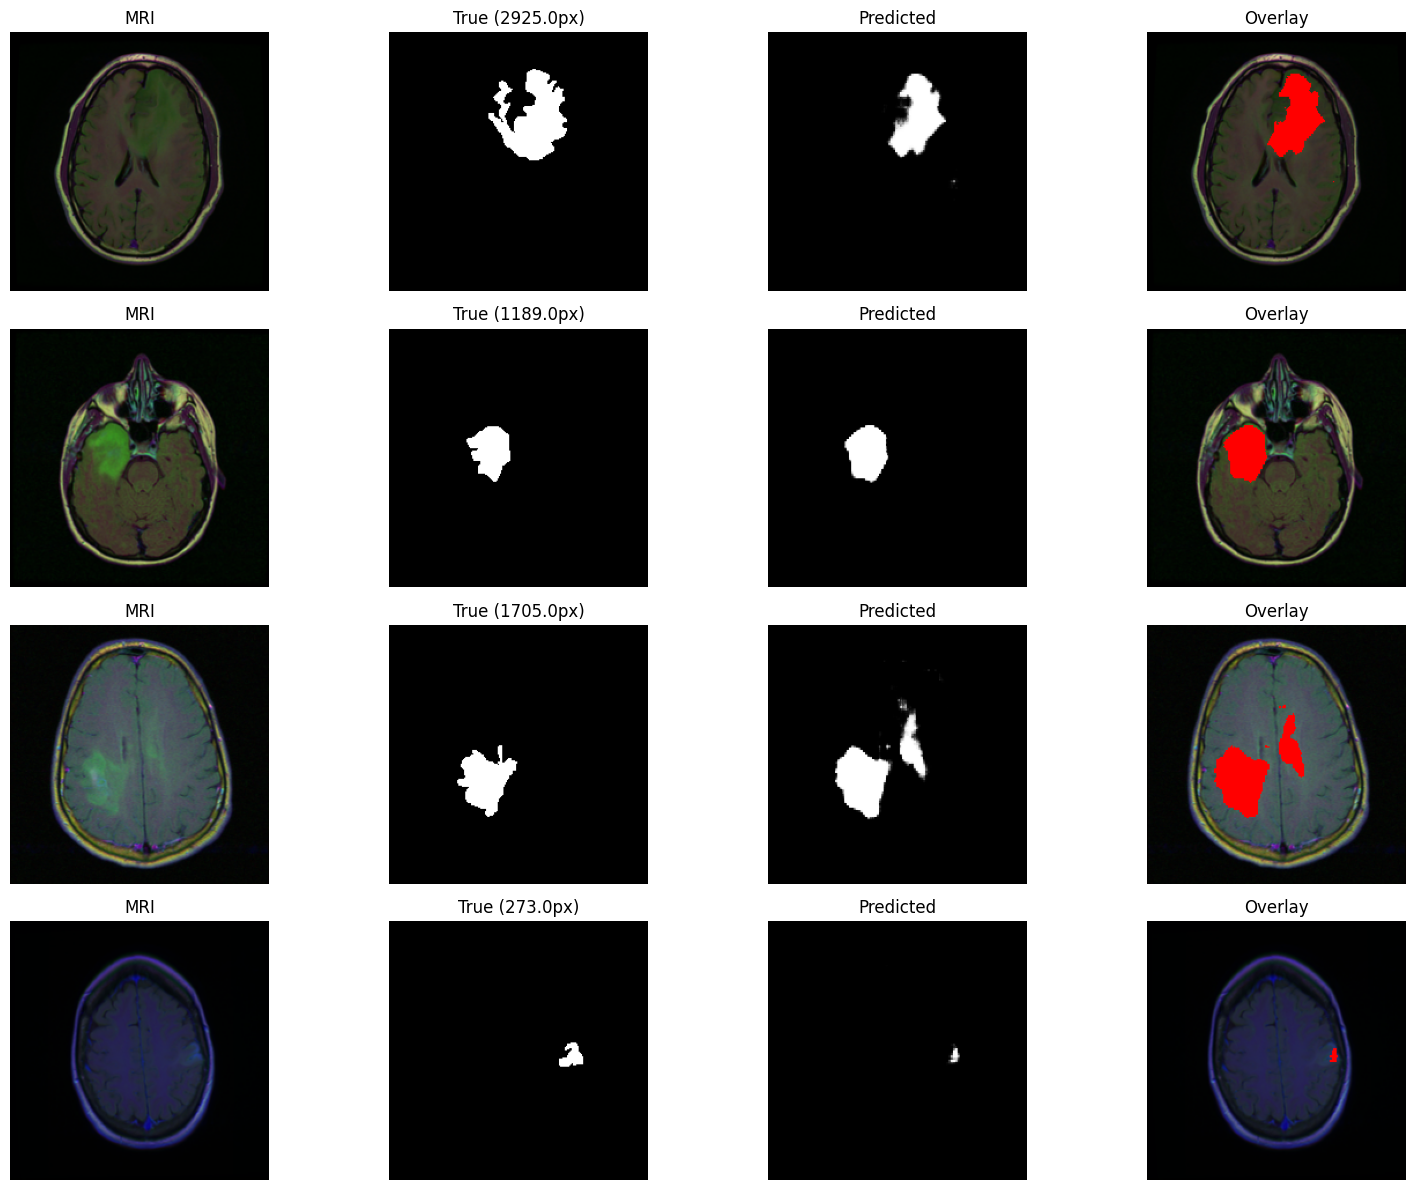


✅ Model saved as 'brain_tumor_resnet50_unet.keras'


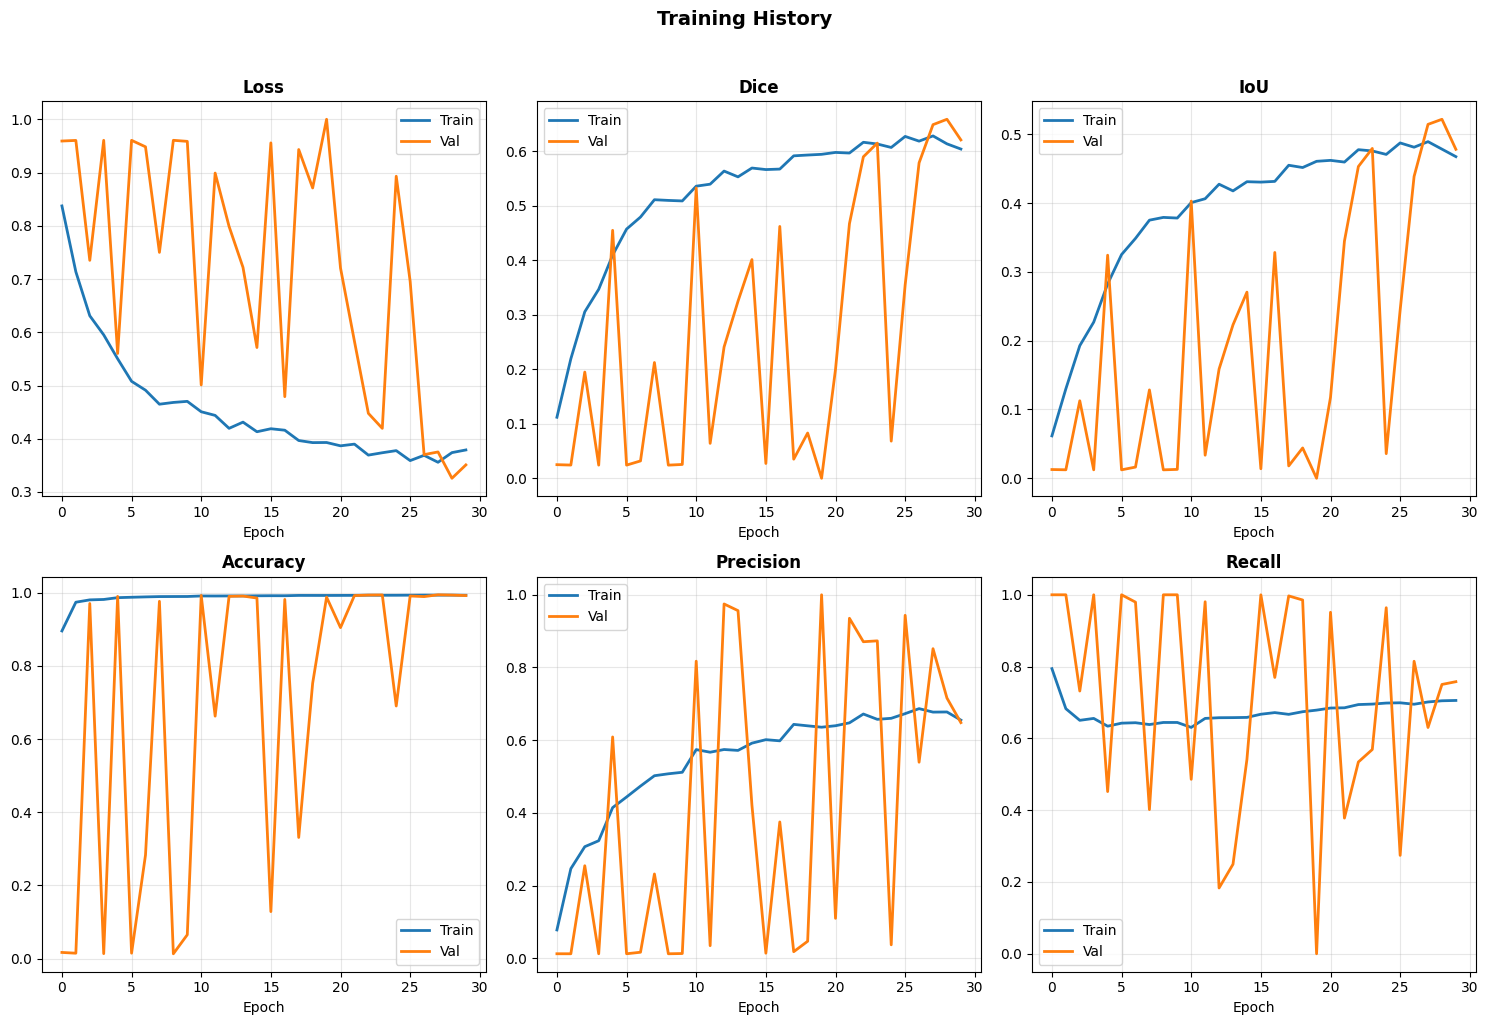


🎯 TRAINING SUMMARY

🏆 Best Validation Dice: 0.6582 (epoch 29)
📊 Final Test Dice: 0.6565
🎉 EXCELLENT: Model is working very well!


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import gc

print("TensorFlow version:", tf.__version__)

# ============================================================================
# DISABLE MIXED PRECISION TO AVOID DTYPE ISSUES
# ============================================================================
tf.keras.mixed_precision.set_global_policy('float32')
print("Mixed precision disabled - using float32")

# ============================================================================
# DATA LOADING
# ============================================================================

def get_file_paths(base_dir):
    """
    Get all image and mask file paths without loading them
    """
    data_dir = os.path.join(base_dir, 'kaggle_3m')
    image_paths = []
    mask_paths = []

    if not os.path.exists(data_dir):
        raise ValueError(f"Data directory {data_dir} does not exist!")

    patient_folders = [f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))
                      and not f.startswith('.')]

    print(f"Found {len(patient_folders)} patient folders")

    for folder in patient_folders:
        folder_path = os.path.join(data_dir, folder)
        files = os.listdir(folder_path)

        mask_files = [f for f in files if f.endswith('_mask.tif')]

        for mask_file in mask_files:
            mask_path = os.path.join(folder_path, mask_file)
            image_file = mask_file.replace('_mask.tif', '.tif')
            image_path = os.path.join(folder_path, image_file)

            if os.path.exists(image_path) and os.path.exists(mask_path):
                image_paths.append(image_path)
                mask_paths.append(mask_path)

    return image_paths, mask_paths

print("Getting file paths...")
base_dir = 'lgg-mri-segmentation'
image_paths, mask_paths = get_file_paths(base_dir)
print(f"Found {len(image_paths)} image-mask pairs")

# Split indices
indices = np.arange(len(image_paths))
train_indices, temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42)

print(f"Training set: {len(train_indices)} samples")
print(f"Validation set: {len(val_indices)} samples")
print(f"Test set: {len(test_indices)} samples")

# ============================================================================
# FIXED LOSS FUNCTIONS WITH DTYPE HANDLING
# ============================================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient with explicit dtype casting
    """
    # Ensure both tensors are float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Explicit casting before multiplication
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)

    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Dice loss
    """
    return 1.0 - dice_coefficient(y_true, y_pred)

def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    """
    Tversky loss with dtype handling
    """
    # Ensure float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Cast to float32
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)

    true_pos = K.sum(y_true_f * y_pred_f)
    false_neg = K.sum(y_true_f * (1.0 - y_pred_f))
    false_pos = K.sum((1.0 - y_true_f) * y_pred_f)

    numerator = true_pos + smooth
    denominator = true_pos + alpha * false_pos + beta * false_neg + smooth

    return 1.0 - (numerator / denominator)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """
    IoU metric with dtype handling
    """
    # Ensure float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Cast to float32
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

# ============================================================================
# SIMPLE BUT EFFECTIVE RESNET50 UNET
# ============================================================================

def build_simple_resnet50_unet(input_shape=(224, 224, 3)):
    """
    Simple ResNet50 UNet with proper dtype handling
    """
    # Force float32 for all layers
    tf.keras.backend.set_floatx('float32')

    # Pre-trained ResNet50
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze first 100 layers
    for layer in base_model.layers[:100]:
        layer.trainable = False
        layer._dtype_policy = tf.keras.mixed_precision.Policy('float32')

    for layer in base_model.layers[100:]:
        layer.trainable = True
        layer._dtype_policy = tf.keras.mixed_precision.Policy('float32')

    # Get feature maps
    skip1 = base_model.get_layer('conv1_relu').output      # 112x112x64
    skip2 = base_model.get_layer('conv2_block3_out').output  # 56x56x256
    skip3 = base_model.get_layer('conv3_block4_out').output  # 28x28x512
    skip4 = base_model.get_layer('conv4_block6_out').output  # 14x14x1024
    bridge = base_model.get_layer('conv5_block3_out').output # 7x7x2048

    print(f"\nFeature map shapes:")
    print(f"skip1: {skip1.shape}")
    print(f"skip2: {skip2.shape}")
    print(f"skip3: {skip3.shape}")
    print(f"skip4: {skip4.shape}")
    print(f"bridge: {bridge.shape}")

    # ========== DECODER ==========
    # Ensure float32 for all operations
    # Upsample bridge (7x7 -> 14x14)
    up1 = layers.Conv2DTranspose(1024, (2, 2), strides=(2, 2), padding='same', dtype='float32')(bridge)
    up1 = layers.BatchNormalization(dtype='float32')(up1)
    up1 = layers.Activation('relu', dtype='float32')(up1)

    # Concatenate with skip4
    concat1 = layers.concatenate([up1, skip4], dtype='float32')
    conv1 = layers.Conv2D(1024, (3, 3), padding='same', dtype='float32')(concat1)
    conv1 = layers.BatchNormalization(dtype='float32')(conv1)
    conv1 = layers.Activation('relu', dtype='float32')(conv1)

    # Upsample 2 (14x14 -> 28x28)
    up2 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same', dtype='float32')(conv1)
    up2 = layers.BatchNormalization(dtype='float32')(up2)
    up2 = layers.Activation('relu', dtype='float32')(up2)

    # Concatenate with skip3
    concat2 = layers.concatenate([up2, skip3], dtype='float32')
    conv2 = layers.Conv2D(512, (3, 3), padding='same', dtype='float32')(concat2)
    conv2 = layers.BatchNormalization(dtype='float32')(conv2)
    conv2 = layers.Activation('relu', dtype='float32')(conv2)

    # Upsample 3 (28x28 -> 56x56)
    up3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same', dtype='float32')(conv2)
    up3 = layers.BatchNormalization(dtype='float32')(up3)
    up3 = layers.Activation('relu', dtype='float32')(up3)

    # Concatenate with skip2
    concat3 = layers.concatenate([up3, skip2], dtype='float32')
    conv3 = layers.Conv2D(256, (3, 3), padding='same', dtype='float32')(concat3)
    conv3 = layers.BatchNormalization(dtype='float32')(conv3)
    conv3 = layers.Activation('relu', dtype='float32')(conv3)

    # Upsample 4 (56x56 -> 112x112)
    up4 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', dtype='float32')(conv3)
    up4 = layers.BatchNormalization(dtype='float32')(up4)
    up4 = layers.Activation('relu', dtype='float32')(up4)

    # Adjust skip1 channels to match (64 -> 128)
    skip1_adjusted = layers.Conv2D(128, (1, 1), padding='same', dtype='float32')(skip1)
    skip1_adjusted = layers.BatchNormalization(dtype='float32')(skip1_adjusted)
    skip1_adjusted = layers.Activation('relu', dtype='float32')(skip1_adjusted)

    # Concatenate with adjusted skip1
    concat4 = layers.concatenate([up4, skip1_adjusted], dtype='float32')
    conv4 = layers.Conv2D(128, (3, 3), padding='same', dtype='float32')(concat4)
    conv4 = layers.BatchNormalization(dtype='float32')(conv4)
    conv4 = layers.Activation('relu', dtype='float32')(conv4)

    # Final upsample to original size (112x112 -> 224x224)
    up5 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', dtype='float32')(conv4)
    up5 = layers.BatchNormalization(dtype='float32')(up5)
    up5 = layers.Activation('relu', dtype='float32')(up5)

    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid', dtype='float32')(up5)

    model = models.Model(inputs=base_model.input, outputs=outputs, name='ResNet50_UNet')

    # Force model to use float32
    model._dtype_policy = tf.keras.mixed_precision.Policy('float32')

    return model

# ============================================================================
# SIMPLE DATA GENERATOR WITH DTYPE CONTROL
# ============================================================================

class SimpleDataGenerator(tf.keras.utils.Sequence):
    """
    Simple generator with explicit dtype control
    """
    def __init__(self, image_paths, mask_paths, indices, batch_size=8,
                 img_size=(224, 224), shuffle=True, augment=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.indices = indices
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size]

        batch_images = []
        batch_masks = []

        for idx in batch_indices:
            # Load image
            image = cv2.imread(self.image_paths[idx])
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

            if image is None or mask is None:
                continue

            # Resize
            image = cv2.resize(image, self.img_size)
            mask = cv2.resize(mask, self.img_size)

            # Convert to float32 explicitly
            image = image.astype(np.float32) / 255.0
            mask = (mask > 0).astype(np.float32)

            # Simple augmentation
            if self.augment:
                image, mask = self.apply_augmentation(image, mask)

            # Add channel dimension
            mask = np.expand_dims(mask, axis=-1)

            batch_images.append(image)
            batch_masks.append(mask)

        if len(batch_images) == 0:
            return (np.zeros((0, *self.img_size, 3), dtype=np.float32),
                    np.zeros((0, *self.img_size, 1), dtype=np.float32))

        return (np.array(batch_images, dtype=np.float32),
                np.array(batch_masks, dtype=np.float32))

    def apply_augmentation(self, image, mask):
        """Simple augmentation"""
        # Random horizontal flip
        if np.random.random() > 0.5:
            image = np.fliplr(image)
            mask = np.fliplr(mask)

        # Random vertical flip
        if np.random.random() > 0.5:
            image = np.flipud(image)
            mask = np.flipud(mask)

        # Random rotation (90 degree steps)
        if np.random.random() > 0.5:
            k = np.random.randint(0, 4)
            image = np.rot90(image, k)
            mask = np.rot90(mask, k)

        # Random brightness
        if np.random.random() > 0.5:
            image = image * np.random.uniform(0.8, 1.2)
            image = np.clip(image, 0.0, 1.0)

        return image.astype(np.float32), mask.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_model():
    """
    Main training function
    """
    print("\n" + "="*60)
    print("TRAINING RESNET50-UNET")
    print("="*60)

    # Build model
    model = build_simple_resnet50_unet()

    # Create data generators
    train_gen = SimpleDataGenerator(
        image_paths, mask_paths, train_indices,
        batch_size=8, shuffle=True, augment=True
    )

    val_gen = SimpleDataGenerator(
        image_paths, mask_paths, val_indices,
        batch_size=8, shuffle=False, augment=False
    )

    # Compile model
    optimizer = Adam(learning_rate=1e-4)

    # Use Tversky loss (good for imbalanced data)
    model.compile(
        optimizer=optimizer,
        loss=tversky_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    model.summary()

    # Callbacks
    callbacks = [
        ModelCheckpoint(
            'best_resnet50_unet.h5',
            monitor='val_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_dice_coefficient',
            patience=15,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        CSVLogger('training_log.csv')
    ]

    # Train
    print("\nStarting training...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_model(model):
    """
    Evaluate model
    """
    print("\n" + "="*60)
    print("EVALUATING MODEL")
    print("="*60)

    test_gen = SimpleDataGenerator(
        image_paths, mask_paths, test_indices,
        batch_size=8, shuffle=False, augment=False
    )

    results = model.evaluate(test_gen, verbose=1)

    print("\n📊 TEST RESULTS:")
    metrics = ['Loss', 'Dice', 'IoU', 'Accuracy', 'Precision', 'Recall']
    for i, metric in enumerate(metrics):
        print(f"  {metric}: {results[i]:.4f}")

    return results

def visualize_predictions(model, num_samples=4):
    """
    Visualize predictions
    """
    print(f"\nVisualizing {num_samples} predictions...")

    # Find samples with tumors
    tumor_samples = []
    for idx in test_indices[:100]:
        mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            mask_resized = cv2.resize(mask, (224, 224))
            if np.sum(mask_resized > 0) > 0:
                tumor_samples.append(idx)
                if len(tumor_samples) >= num_samples:
                    break

    if len(tumor_samples) < num_samples:
        tumor_samples = test_indices[:num_samples]

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*3))

    for i, idx in enumerate(tumor_samples[:num_samples]):
        # Load and process
        image = cv2.imread(image_paths[idx])
        mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

        image_resized = cv2.resize(image, (224, 224))
        mask_resized = cv2.resize(mask, (224, 224))

        image_norm = image_resized.astype(np.float32) / 255.0
        mask_binary = (mask_resized > 0).astype(np.float32)

        # Predict
        pred = model.predict(np.expand_dims(image_norm, axis=0), verbose=0)
        pred_binary = (pred[0] > 0.5).astype(np.float32)

        # Display
        img_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title('MRI')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_binary, cmap='gray')
        axes[i, 1].set_title(f'True ({np.sum(mask_binary)}px)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred[0].squeeze(), cmap='gray')
        axes[i, 2].set_title('Predicted')
        axes[i, 2].axis('off')

        overlay = img_rgb.copy()
        overlay[pred_binary.squeeze() > 0.5] = [255, 0, 0]
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# ============================================================================
# FALLBACK MODEL (IN CASE RESNET50 FAILS)
# ============================================================================

def build_fallback_model():
    """
    Ultra-simple model as fallback
    """
    inputs = layers.Input((224, 224, 3), dtype='float32')

    # Simple encoder
    x = layers.Conv2D(16, 3, padding='same', activation='relu', dtype='float32')(inputs)
    x = layers.MaxPooling2D(2, dtype='float32')(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu', dtype='float32')(x)
    x = layers.MaxPooling2D(2, dtype='float32')(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu', dtype='float32')(x)

    # Simple decoder
    x = layers.UpSampling2D(2, dtype='float32')(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', dtype='float32')(x)

    x = layers.UpSampling2D(2, dtype='float32')(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu', dtype='float32')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='Fallback_Model')
    model._dtype_policy = tf.keras.mixed_precision.Policy('float32')

    return model

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    try:
        # Clean memory
        gc.collect()

        print("="*60)
        print("🧠 BRAIN TUMOR SEGMENTATION (FIXED DTYPE VERSION)")
        print("="*60)

        # Set random seeds
        np.random.seed(42)
        tf.random.set_seed(42)

        # Try training with ResNet50
        print("\nAttempting ResNet50 UNet training...")
        model, history = train_model()

        # Evaluate
        results = evaluate_model(model)

        # Visualize
        visualize_predictions(model, num_samples=4)

        # Save model
        model.save('brain_tumor_resnet50_unet.keras')
        print("\n✅ Model saved as 'brain_tumor_resnet50_unet.keras'")

        # Plot training history
        if history:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))

            metrics = ['loss', 'dice_coefficient', 'iou_metric',
                      'binary_accuracy', 'precision', 'recall']
            titles = ['Loss', 'Dice', 'IoU', 'Accuracy', 'Precision', 'Recall']

            for idx, (metric, title) in enumerate(zip(metrics, titles)):
                row = idx // 3
                col = idx % 3

                if metric in history.history:
                    axes[row, col].plot(history.history[metric], label='Train', linewidth=2)
                    axes[row, col].plot(history.history[f'val_{metric}'], label='Val', linewidth=2)
                    axes[row, col].set_title(title, fontweight='bold')
                    axes[row, col].set_xlabel('Epoch')
                    axes[row, col].legend()
                    axes[row, col].grid(True, alpha=0.3)

            plt.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

            # Print summary
            print("\n" + "="*60)
            print("🎯 TRAINING SUMMARY")
            print("="*60)

            if 'val_dice_coefficient' in history.history:
                best_val_dice = max(history.history['val_dice_coefficient'])
                best_epoch = np.argmax(history.history['val_dice_coefficient']) + 1

                print(f"\n🏆 Best Validation Dice: {best_val_dice:.4f} (epoch {best_epoch})")
                print(f"📊 Final Test Dice: {results[1]:.4f}")

                # Performance assessment
                if best_val_dice > 0.5:
                    print("🎉 EXCELLENT: Model is working very well!")
                elif best_val_dice > 0.3:
                    print("✅ GOOD: Model is learning effectively")
                elif best_val_dice > 0.1:
                    print("⚠️  FAIR: Needs some improvement")
                else:
                    print("❌ POOR: Check data and model architecture")

    except Exception as e:
        print(f"\n❌ Error with ResNet50: {e}")

        # Try fallback model
        print("\n🔄 Trying ultra-simple fallback model...")

        try:
            # Build fallback model
            fallback_model = build_fallback_model()

            # Create simple data generators with smaller dataset
            small_train_indices = train_indices[:500]  # Use smaller subset
            small_val_indices = val_indices[:100]

            train_gen_simple = SimpleDataGenerator(
                image_paths, mask_paths, small_train_indices,
                batch_size=8, shuffle=True, augment=True
            )

            val_gen_simple = SimpleDataGenerator(
                image_paths, mask_paths, small_val_indices,
                batch_size=8, shuffle=False, augment=False
            )

            # Compile with simple loss
            fallback_model.compile(
                optimizer=Adam(learning_rate=1e-3),
                loss='binary_crossentropy',
                metrics=[dice_coefficient, iou_metric]
            )

            # Train
            print("Training fallback model...")
            fallback_history = fallback_model.fit(
                train_gen_simple,
                validation_data=val_gen_simple,
                epochs=10,
                verbose=1
            )

            # Save
            fallback_model.save('brain_tumor_fallback_model.keras')
            print("✅ Fallback model saved as 'brain_tumor_fallback_model.keras'")

            # Quick test
            test_gen_simple = SimpleDataGenerator(
                image_paths, mask_paths, test_indices[:50],
                batch_size=8, shuffle=False, augment=False
            )

            fallback_results = fallback_model.evaluate(test_gen_simple, verbose=0)
            print(f"\nFallback model test Dice: {fallback_results[1]:.4f}")

        except Exception as fallback_error:
            print(f"\n❌ Fallback model also failed: {fallback_error}")
            print("\n🔧 Troubleshooting steps:")
            print("1. Check dataset paths and files")
            print("2. Reduce batch size to 4")
            print("3. Try without data augmentation")
            print("4. Check GPU memory availability")

In [13]:
# Save BEST model in .h5 format
model.save("brain_tumor_resnet50_unet_best.h5")

print("✅ Best model saved as brain_tumor_resnet50_unet_best.h5")


✅ Best model saved as brain_tumor_resnet50_unet_best.h5


In [14]:
import os

print(os.path.exists("brain_tumor_resnet50_unet_best.h5"))


True


In [15]:
from google.colab import files
files.download("brain_tumor_resnet50_unet_best.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>